### Regresión logística - Predecir si un alumno entre o no en la universidad

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [6]:
## Cargamos los datos

data = pd.read_excel(r"admitidos.xlsx")
display(data)

,Horas_estudio,Nota_examen,Admitido
0,3,43.185412,0
1,7,50.346164,0
2,29,99.396287,1
3,13,68.363516,0
4,1,44.349536,0
...,...,...,...
1135,20,84.216603,1
1136,9,58.881115,0
1137,0,35.570694,0
1138,2,48.906019,0


In [17]:
# Definimos los conjuntos de variables

X = data[["Horas_estudio","Nota_examen"]]
y = data["Admitido"]

In [20]:
# Dividimos el data set en TRAIN y TEST

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("Filas en TRAIN:", X_train.shape[0])
print("Filas en TEST: ", X_test.shape[0])

Filas en TRAIN: 912
Filas en TEST:  228


In [22]:
# Construcción del modelo de regresión logística

model = LogisticRegression()

In [24]:
print("B0: ", model.intercept_)
print(model.coef_)

B0:  [-85.10606623]
[[-0.00726372  1.13600268]]


In [25]:
# Mostramos el intercepto del modelo
print("Intercepto (β0):", round(model.intercept_[0], 4))
print()

# Mostramos cada coeficiente junto a su variable
print("Coeficientes:")
for variable, beta in zip(X_train.columns, model.coef_[0]):
    print(variable.ljust(20), ":", round(beta, 4))

Intercepto (β0): -85.1061

Coeficientes:
Horas_estudio        : -0.0073
Nota_examen          : 1.136


In [23]:
# Entrenamiento del modelo

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [28]:
# Cálculo de predicciones
y_pred = model.predict(X_test)

In [29]:
# Evaluación del modelo

# Matriz de confusión
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()

# Accuracy
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print()

# Reporte completo (precision, recall, f1-score por clase)
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[167   0]
 [  2  59]]

Accuracy: 0.9912

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       167
           1       1.00      0.97      0.98        61

    accuracy                           0.99       228
   macro avg       0.99      0.98      0.99       228
weighted avg       0.99      0.99      0.99       228



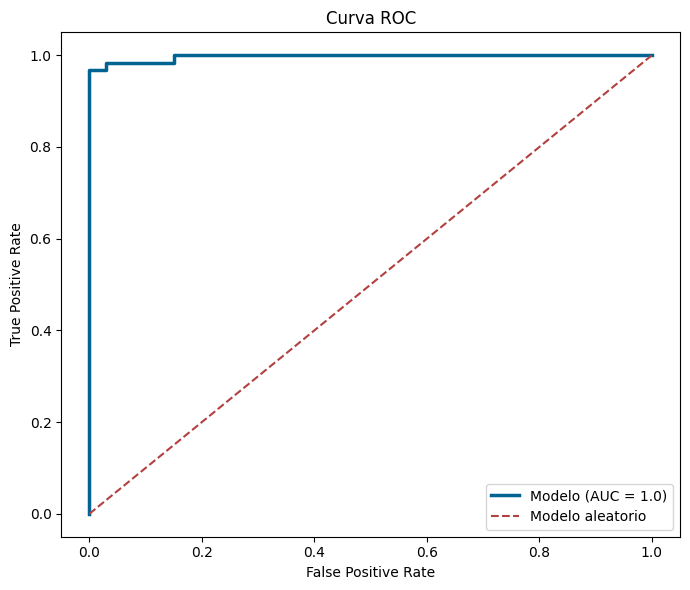

In [32]:
# Curva ROC

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Paleta de marca
COLOR_PRINCIPAL = "#016393"
COLOR_CONTEXTO = "#B2403e"

# Probabilidades predichas (no clases, queremos la probabilidad de la clase 1)
y_prob = model.predict_proba(X_test)[:, 1]

# Curva ROC: tasa de falsos positivos (fpr) vs tasa de verdaderos positivos (tpr)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC: área bajo la curva ROC
auc = roc_auc_score(y_test, y_prob)

# Gráfico
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color=COLOR_PRINCIPAL, linewidth=2.5, label="Modelo (AUC = " + str(round(auc, 2)) + ")")
ax.plot([0, 1], [0, 1], color=COLOR_CONTEXTO, linestyle="--", linewidth=1.5, label="Modelo aleatorio")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curva ROC")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [33]:
# Construir el modelo con otra metodologia para Refresion logistica 

import statsmodels.api as sm 

#hacer el split train test

In [34]:
# Definimos los conjuntos de variables

X = data[["Horas_estudio","Nota_examen"]]
y = data["Admitido"]

In [35]:
# Agregamos la constante a la matriz X (GENERE UN BETA 0)

X = sm.add_constant(X)


In [36]:
#Construir el modelo 

model2= sm.Logit(y,X)
result = model2.fit()

Optimization terminated successfully.
         Current function value: 0.040648
         Iterations 13


In [ ]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:               Admitido   No. Observations:                 1140
Model:                          Logit   Df Residuals:                     1137
Method:                           MLE   Df Model:                            2
Date:                Tue, 30 Jun 2026   Pseudo R-squ.:                  0.9250
Time:                        17:28:06   Log-Likelihood:                -46.338
converged:                       True   LL-Null:                       -618.14
Covariance Type:            nonrobust   LLR p-value:                4.678e-249
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -70.5700     11.468     -6.154      0.000     -93.047     -48.093
Horas_estudio     0.1381      0.185      0.747      0.455      -0.224       0.501
Nota_examen       0.9083      0.170     

: 

nos quedamos con el pseudo r 2, tabla de los betas